# TensorFlow Lite Micro Hello World (Colab)
This notebook adapts your Python files from the TensorFlow Lite Micro Hello World example into a clean, step-by-step Colab flow.

What you will do:
- Install dependencies
- Train a small sine-regression model
- Export a float TFLite model
- Create an int8 quantized TFLite model
- Evaluate predictions vs. ground truth

In [1]:
# Colab setup: install required packages
!pip -q install tensorflow absl-py matplotlib


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## 1) Training Utilities
This section keeps your original training flow and model conversion logic with minimal changes, while using regular Python parameters instead of command-line flags.

In [2]:
import math
import os

from absl import logging
import numpy as np
import tensorflow as tf


def get_data():
    """
    The code will generate a set of random `x` values,calculate their sine
    values.
    """
    # Generate a uniformly distributed set of random numbers in the range from
    # 0 to 2π, which covers a complete sine wave oscillation
    x_values = np.random.uniform(low=0, high=2 * math.pi, size=1000).astype(np.float32)

    # Shuffle the values to guarantee they're not in order
    np.random.shuffle(x_values)

    # Calculate the corresponding sine values
    y_values = np.sin(x_values).astype(np.float32)

    return (x_values, y_values)


def create_model() -> tf.keras.Model:
    model = tf.keras.Sequential()

    # First layer takes a scalar input and feeds it through 16 "neurons". The
    # neurons decide whether to activate based on the 'relu' activation function.
    model.add(tf.keras.layers.Dense(32, activation="relu", input_shape=(1,)))

    # The new second and third layer will help the network learn more complex
    # representations
    model.add(tf.keras.layers.Dense(32, activation="relu"))

    # Final layer is a single neuron, since we want to output a single value
    model.add(tf.keras.layers.Dense(1))

    # Compile the model using the standard 'adam' optimizer and the mean squared
    # error or 'mse' loss function for regression.
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])

    return model


def convert_tflite_model(model):
    """Convert the save TF model to tflite model, then save it as .tflite flatbuffer format
    Args:
        model (tf.keras.Model): the trained hello_world Model
    Returns:
        The converted model in serialized format.
    """
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    return tflite_model


def save_tflite_model(tflite_model, save_dir, model_name):
    """save the converted tflite model
    Args:
        tflite_model (binary): the converted model in serialized format.
        save_dir (str): the save directory
        model_name (str): model name to be saved
    """
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    save_path = os.path.join(save_dir, model_name)
    with open(save_path, "wb") as f:
        f.write(tflite_model)
    logging.info("Tflite model saved to %s", save_dir)


def train_model(
    epochs,
    x_values,
    y_values,
    save_tf_model=False,
    save_dir="hello_world_models",
):
    """Train keras hello_world model
    Args: epochs (int) : number of epochs to train the model
        x_train (numpy.array): list of the training data
        y_train (numpy.array): list of the corresponding array
    Returns:
        tf.keras.Model: A trained keras hello_world model
    """
    model = create_model()
    model.fit(
        x_values,
        y_values,
        epochs=epochs,
        validation_split=0.2,
        batch_size=64,
        verbose=2,
    )

    if save_tf_model:
        # Keras 3: export SavedModel directory for TFLite conversion.
        if hasattr(model, "export"):
            model.export(save_dir)
        else:
            tf.saved_model.save(model, save_dir)
        logging.info("TF model saved to %s", save_dir)

    return model


def train(epochs=500, save_dir="hello_world_models", save_tf_model=True):
    x_values, y_values = get_data()
    trained_model = train_model(
        epochs, x_values, y_values, save_tf_model=save_tf_model, save_dir=save_dir
    )

    # Convert and save the model to .tflite
    tflite_model = convert_tflite_model(trained_model)
    save_tflite_model(tflite_model, save_dir, model_name="hello_world_float.tflite")

I0000 00:00:1790982338.831206    9605 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790982338.832290    9605 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790982338.907817    9605 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790982340.722241    9605 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790982340.722730    9605 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### Run Training
This executes the full training process and writes:
- float TFLite model: hello_world_models/hello_world_float.tflite
- SavedModel directory (for quantization): hello_world_models

In [3]:
# Optional: tweak before running
EPOCHS = 300
SAVE_TF_MODEL = True
SAVE_DIR = "hello_world_models"

train(epochs=EPOCHS, save_dir=SAVE_DIR, save_tf_model=SAVE_TF_MODEL)

site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1790982341.589914    9605 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/300


13/13 - 1s - 114ms/step - loss: 1.9359 - mae: 1.1313 - val_loss: 1.5329 - val_mae: 1.0765


Epoch 2/300


13/13 - 0s - 9ms/step - loss: 1.0552 - mae: 0.8904 - val_loss: 0.8893 - val_mae: 0.8553


...

Saved artifact at 'hello_world_models'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139672229531664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139672229532432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139672229534928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139672229535312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139672229533584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139672229535696: TensorSpec(shape=(), dtype=tf.resource, name=None)


INFO:tensorflow:Assets written to: /tmp/tmpe94gg6t2/assets


INFO:tensorflow:Assets written to: /tmp/tmpe94gg6t2/assets


Saved artifact at '/tmp/tmpe94gg6t2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139672229531664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139672229532432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139672229534928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139672229535312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139672229533584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139672229535696: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1790982381.971437    9605 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790982381.971489    9605 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790982381.971826    9605 reader.cc:83] Reading SavedModel from: /tmp/tmpe94gg6t2
I0000 00:00:1790982381.972282    9605 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1790982381.972292    9605 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpe94gg6t2
I0000 00:00:1790982381.975779    9605 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1790982381.977150    9605 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1790982382.009657    9605 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpe94gg6t2
I0000 00:00:1790982382.017998    9605 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 46184 microseconds.
I0000 00:00:1790982382.028559    9605

## 2) Evaluation Utilities
This section defines evaluation helpers. You can compare prediction quality using either the TFLM runtime path or the TF Lite interpreter path.

In [4]:
import os
from absl import logging
import numpy as np
import matplotlib.pyplot as plt

runtime = None
try:
    from tflite_micro.python.tflite_micro import runtime
except ImportError:
    logging.warning(
        "tflite_micro runtime is not installed. Falling back to TF Lite interpreter path."
    )

OpResolverType = None
try:
    import ai_edge_litert.interpreter as tflite_interp

    try:
        from ai_edge_litert.interpreter import OpResolverType
    except ImportError:
        OpResolverType = None
except ImportError:
    try:
        import tflite_runtime.interpreter as tflite_interp

        try:
            from tflite_runtime.interpreter import OpResolverType
        except ImportError:
            OpResolverType = None
    except ImportError:
        try:
            import tensorflow.lite as tflite_interp
        except ImportError as exc:
            raise ImportError(
                "Could not import ai_edge_litert, tflite_runtime, or tensorflow.lite."
            ) from exc

# __file__ is not available in notebooks, so use cwd in that case.
_PREFIX_PATH = os.path.dirname(__file__) if "__file__" in globals() else os.getcwd()


def invoke_tflm_interpreter(
    input_shape, interpreter, x_value, input_index, output_index
):
    input_data = np.reshape(x_value, input_shape)
    interpreter.set_input(input_data, input_index)
    interpreter.invoke()
    y_quantized = np.reshape(interpreter.get_output(output_index), -1)[0]
    return y_quantized


def prepare_quantized_input(x_value, input_shape, input_details):
    input_data = np.reshape(x_value, input_shape)
    quantization = input_details.get("quantization", (0.0, 0))
    scale, zero_point = quantization

    if input_details["dtype"] in (np.int8, np.uint8) and scale not in (0, 0.0):
        quantized = np.round(input_data / scale + zero_point)
        dtype_info = np.iinfo(input_details["dtype"])
        quantized = np.clip(quantized, dtype_info.min, dtype_info.max)
        return quantized.astype(input_details["dtype"])

    return input_data.astype(input_details["dtype"])


def dequantize_output(output_tensor, output_details):
    output_value = np.reshape(output_tensor, -1)[0]
    quantization = output_details.get("quantization", (0.0, 0))
    scale, zero_point = quantization

    if output_details["dtype"] in (np.int8, np.uint8) and scale not in (0, 0.0):
        return (int(output_value) - zero_point) * scale

    return float(output_value)


def invoke_tflite_interpreter(
    input_shape, interpreter, x_value, input_details, output_details
):
    input_data = prepare_quantized_input(x_value, input_shape, input_details)
    interpreter.set_tensor(input_details["index"], input_data)
    interpreter.invoke()
    tflite_output = interpreter.get_tensor(output_details["index"])
    return dequantize_output(tflite_output, output_details)


# Generate a list of random floats in the range of 0 to 2*pi.
def generate_random_int8_input(sample_count=1000):
    np.random.seed(42)
    x_values = np.random.uniform(low=0, high=2 * np.pi, size=sample_count).astype(
        np.int8
    )
    return x_values


# Generate a list of random floats in the range of 0 to 2*pi.
def generate_random_float_input(sample_count=1000):
    np.random.seed(42)
    x_values = np.random.uniform(low=0, high=2 * np.pi, size=sample_count).astype(
        np.float32
    )
    return x_values


def calculate_regression_metrics(y_true, y_pred):
    errors = y_pred - y_true
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(np.square(errors))))
    return {"mae": mae, "rmse": rmse}


# Invoke the tflm interpreter with x_values in the range of [0, 2*PI] and
# returns the prediction of the interpreter.
def get_tflm_prediction(model_path, x_values):
    if runtime is None:
        raise ImportError(
            "tflite_micro runtime is unavailable. Set use_tflite=True to evaluate with TF Lite."
        )

    tflm_interpreter = runtime.Interpreter.from_file(model_path)

    input_shape = np.array(tflm_interpreter.get_input_details(0).get("shape"))

    y_predictions = np.empty(x_values.size, dtype=np.float32)

    for i, x_value in enumerate(x_values):
        y_predictions[i] = invoke_tflm_interpreter(
            input_shape, tflm_interpreter, x_value, input_index=0, output_index=0
        )
    return y_predictions


# Invoke the tflite interpreter with x_values in the range of [0, 2*PI] and
# returns the prediction of the interpreter.
def get_tflite_prediction(model_path, x_values):
    kwargs = {"model_path": model_path}
    if OpResolverType is not None and hasattr(OpResolverType, "BUILTIN_REF"):
        kwargs["experimental_op_resolver_type"] = OpResolverType.BUILTIN_REF
    else:
        logging.info(
            "OpResolverType.BUILTIN_REF is unavailable. Using the interpreter defaults."
        )

    tflite_interpreter = tflite_interp.Interpreter(**kwargs)
    tflite_interpreter.allocate_tensors()

    input_details = tflite_interpreter.get_input_details()[0]
    output_details = tflite_interpreter.get_output_details()[0]
    input_shape = np.array(input_details.get("shape"))

    y_predictions = np.empty(x_values.size, dtype=np.float32)

    for i, x_value in enumerate(x_values):
        y_predictions[i] = invoke_tflite_interpreter(
            input_shape,
            tflite_interpreter,
            x_value,
            input_details,
            output_details,
        )
    return y_predictions


def evaluate(
    model_path="hello_world_models/hello_world_float.tflite",
    use_tflite=False,
    model_label=None,
    show_plot=True,
):
    x_values = generate_random_float_input()
    y_true_values = np.sin(x_values).astype(np.float32)

    run_with_tflite = use_tflite or runtime is None
    if runtime is None and not use_tflite:
        logging.warning(
            "use_tflite was False, but tflite_micro is unavailable. Using TF Lite interpreter."
        )

    if model_label is None:
        model_label = "TFLite" if run_with_tflite else "TFLM"

    if run_with_tflite:
        y_predictions = get_tflite_prediction(model_path, x_values)
        prediction_label = f"{model_label} Prediction"
    else:
        y_predictions = get_tflm_prediction(model_path, x_values)
        prediction_label = f"{model_label} Prediction"

    metrics = calculate_regression_metrics(y_true_values, y_predictions)
    print(
        f"{model_label} MAE: {metrics['mae']:.6f} | {model_label} RMSE: {metrics['rmse']:.6f}"
    )

    if show_plot:
        plt.plot(x_values, y_predictions, "b.", label=prediction_label)
        plt.plot(x_values, y_true_values, "r.", label="Actual values")
        plt.title(
            f"{model_label} Evaluation | MAE={metrics['mae']:.4f}, RMSE={metrics['rmse']:.4f}"
        )
        plt.legend()
        plt.show()

    return metrics

## 3) Quantization Utilities
This section keeps your post-training quantization code and converts the SavedModel into an int8 TFLite model.

In [5]:
"""This script can create a quant(int8) model from the saved TF model.
"""
import math
import os

from absl import logging
import numpy as np
import tensorflow as tf


def get_data():
    """
    The code will generate a set of random `x` values
    """
    # Generate a uniformly distributed set of random numbers in the range from
    # 0 to 2π, which covers a complete sine wave oscillation
    x_values = np.random.uniform(low=0, high=2 * math.pi, size=1000).astype(np.float32)

    # Shuffle the values to guarantee they're not in order
    np.random.shuffle(x_values)

    return x_values


def save_tflite_model(tflite_model, target_dir, model_name):
    """save the converted tflite model
    Args:
        tflite_model (binary): the converted model in serialized format.
        save_dir (str): the save directory
        model_name (str): model name to be saved
    """
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
    save_path = os.path.join(target_dir, model_name)
    with open(save_path, "wb") as f:
        f.write(tflite_model)
    logging.info("Tflite model saved to %s", target_dir)


def convert_quantized_tflite_model(source_model_dir, x_values):
    """Convert the save TF model to tflite model, then save it as .tflite
    flatbuffer format

    Args:
        source_model_dir (tf.keras.Model): the trained hello_world float Model dir
        x_train (numpy.array): list of the training data

    Returns:
        The converted model in serialized format.
    """

    # Convert the model to the TensorFlow Lite format with quantization
    def representative_dataset(num_samples=500):
        for i in range(num_samples):
            yield [x_values[i].reshape(1, 1)]

    converter = tf.lite.TFLiteConverter.from_saved_model(source_model_dir)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    converter.representative_dataset = representative_dataset
    tflite_model = converter.convert()
    return tflite_model


def quantize(
    source_model_dir="hello_world_models",
    target_dir="hello_world_models",
):
    x_values = get_data()
    quantized_tflite_model = convert_quantized_tflite_model(source_model_dir, x_values)
    save_tflite_model(
        quantized_tflite_model, target_dir, model_name="hello_world_int8.tflite"
    )

### Run Quantization
This generates hello_world_models/hello_world_int8.tflite from the SavedModel exported during training.

In [6]:
SOURCE_MODEL_DIR = "hello_world_models"
TARGET_DIR = "hello_world_models"

quantize(source_model_dir=SOURCE_MODEL_DIR, target_dir=TARGET_DIR)

W0000 00:00:1790982382.449409    9605 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790982382.449457    9605 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790982382.449651    9605 reader.cc:83] Reading SavedModel from: hello_world_models
I0000 00:00:1790982382.450594    9605 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1790982382.450609    9605 reader.cc:147] Reading SavedModel debug info (if present) from: hello_world_models
I0000 00:00:1790982382.455085    9605 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1790982382.479173    9605 loader.cc:220] Running initialization op on SavedModel bundle at path: hello_world_models
I0000 00:00:1790982382.487713    9605 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 38078 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1790982382.568166    9605 flatbuffer_expo

## 4) Run Evaluation
By default this plots predictions from the float TFLite model. You can enable pure TF Lite interpreter mode with `use_tflite=True`.

Float model MAE: 0.009936 | Float model RMSE: 0.013852


site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


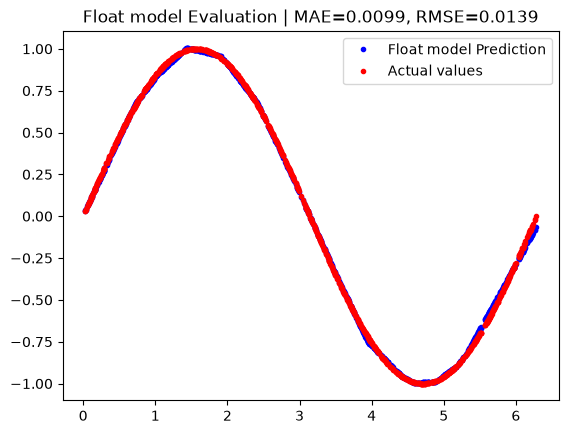

In [7]:
EVAL_MODEL_PATH = "hello_world_models/hello_world_float.tflite"
USE_TFLITE = False  # Set True to force TF Lite interpreter path

float_metrics = evaluate(
    model_path=EVAL_MODEL_PATH,
    use_tflite=USE_TFLITE,
    model_label="Float model",
)

In [8]:
# 5) Run Quantized Evaluation
# Use the int8 model path below to evaluate the quantized model.
# The evaluator now quantizes inputs and dequantizes outputs automatically.

Quantized model MAE: 0.011615 | Quantized model RMSE: 0.016460


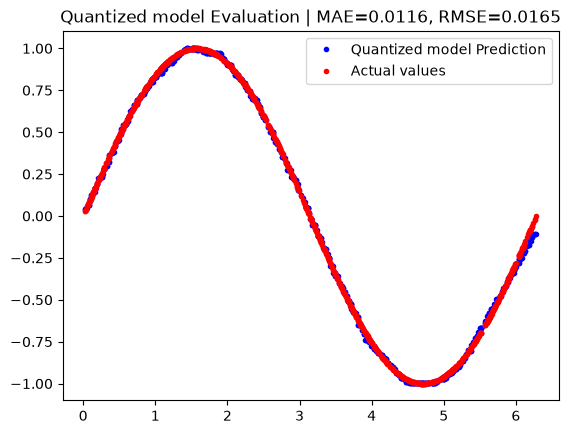

In [9]:
QUANTIZED_MODEL_PATH = "hello_world_models/hello_world_int8.tflite"

# Quantized evaluation should use the TF Lite interpreter path in Colab.
quantized_metrics = evaluate(
    model_path=QUANTIZED_MODEL_PATH,
    use_tflite=True,
    model_label="Quantized model",
)

## 6) Compare Results
This cell summarizes the error metrics for the float and quantized models side by side so you can see the quantization impact directly.

In [10]:
comparison_rows = [
    ("Float model", float_metrics["mae"], float_metrics["rmse"]),
    ("Quantized model", quantized_metrics["mae"], quantized_metrics["rmse"]),
]

print(f"{'Model':<18} {'MAE':>12} {'RMSE':>12}")
print("-" * 44)
for model_name, mae_value, rmse_value in comparison_rows:
    print(f"{model_name:<18} {mae_value:>12.6f} {rmse_value:>12.6f}")

mae_delta = quantized_metrics["mae"] - float_metrics["mae"]
rmse_delta = quantized_metrics["rmse"] - float_metrics["rmse"]

print("\nDelta (quantized - float)")
print(f"MAE delta : {mae_delta:.6f}")
print(f"RMSE delta: {rmse_delta:.6f}")

comparison_rows

Model                       MAE         RMSE
--------------------------------------------
Float model            0.009936     0.013852
Quantized model        0.011615     0.016460

Delta (quantized - float)
MAE delta : 0.001679
RMSE delta: 0.002608


[('Float model', 0.009936012327671051, 0.013852467760443687),
 ('Quantized model', 0.011615469120442867, 0.01646004617214203)]